We are going to sum up the documents that we have in the folder
"documents". The pdfs from this lesson are located on the path
"/fp/projects01/ec443/documents". In task number 2 in the chapter on
"Easy login", you were asked to make your own documents folder in your
home directory. In case you did not get the time, you will now get a
second chance. Do the task below, if not done before:

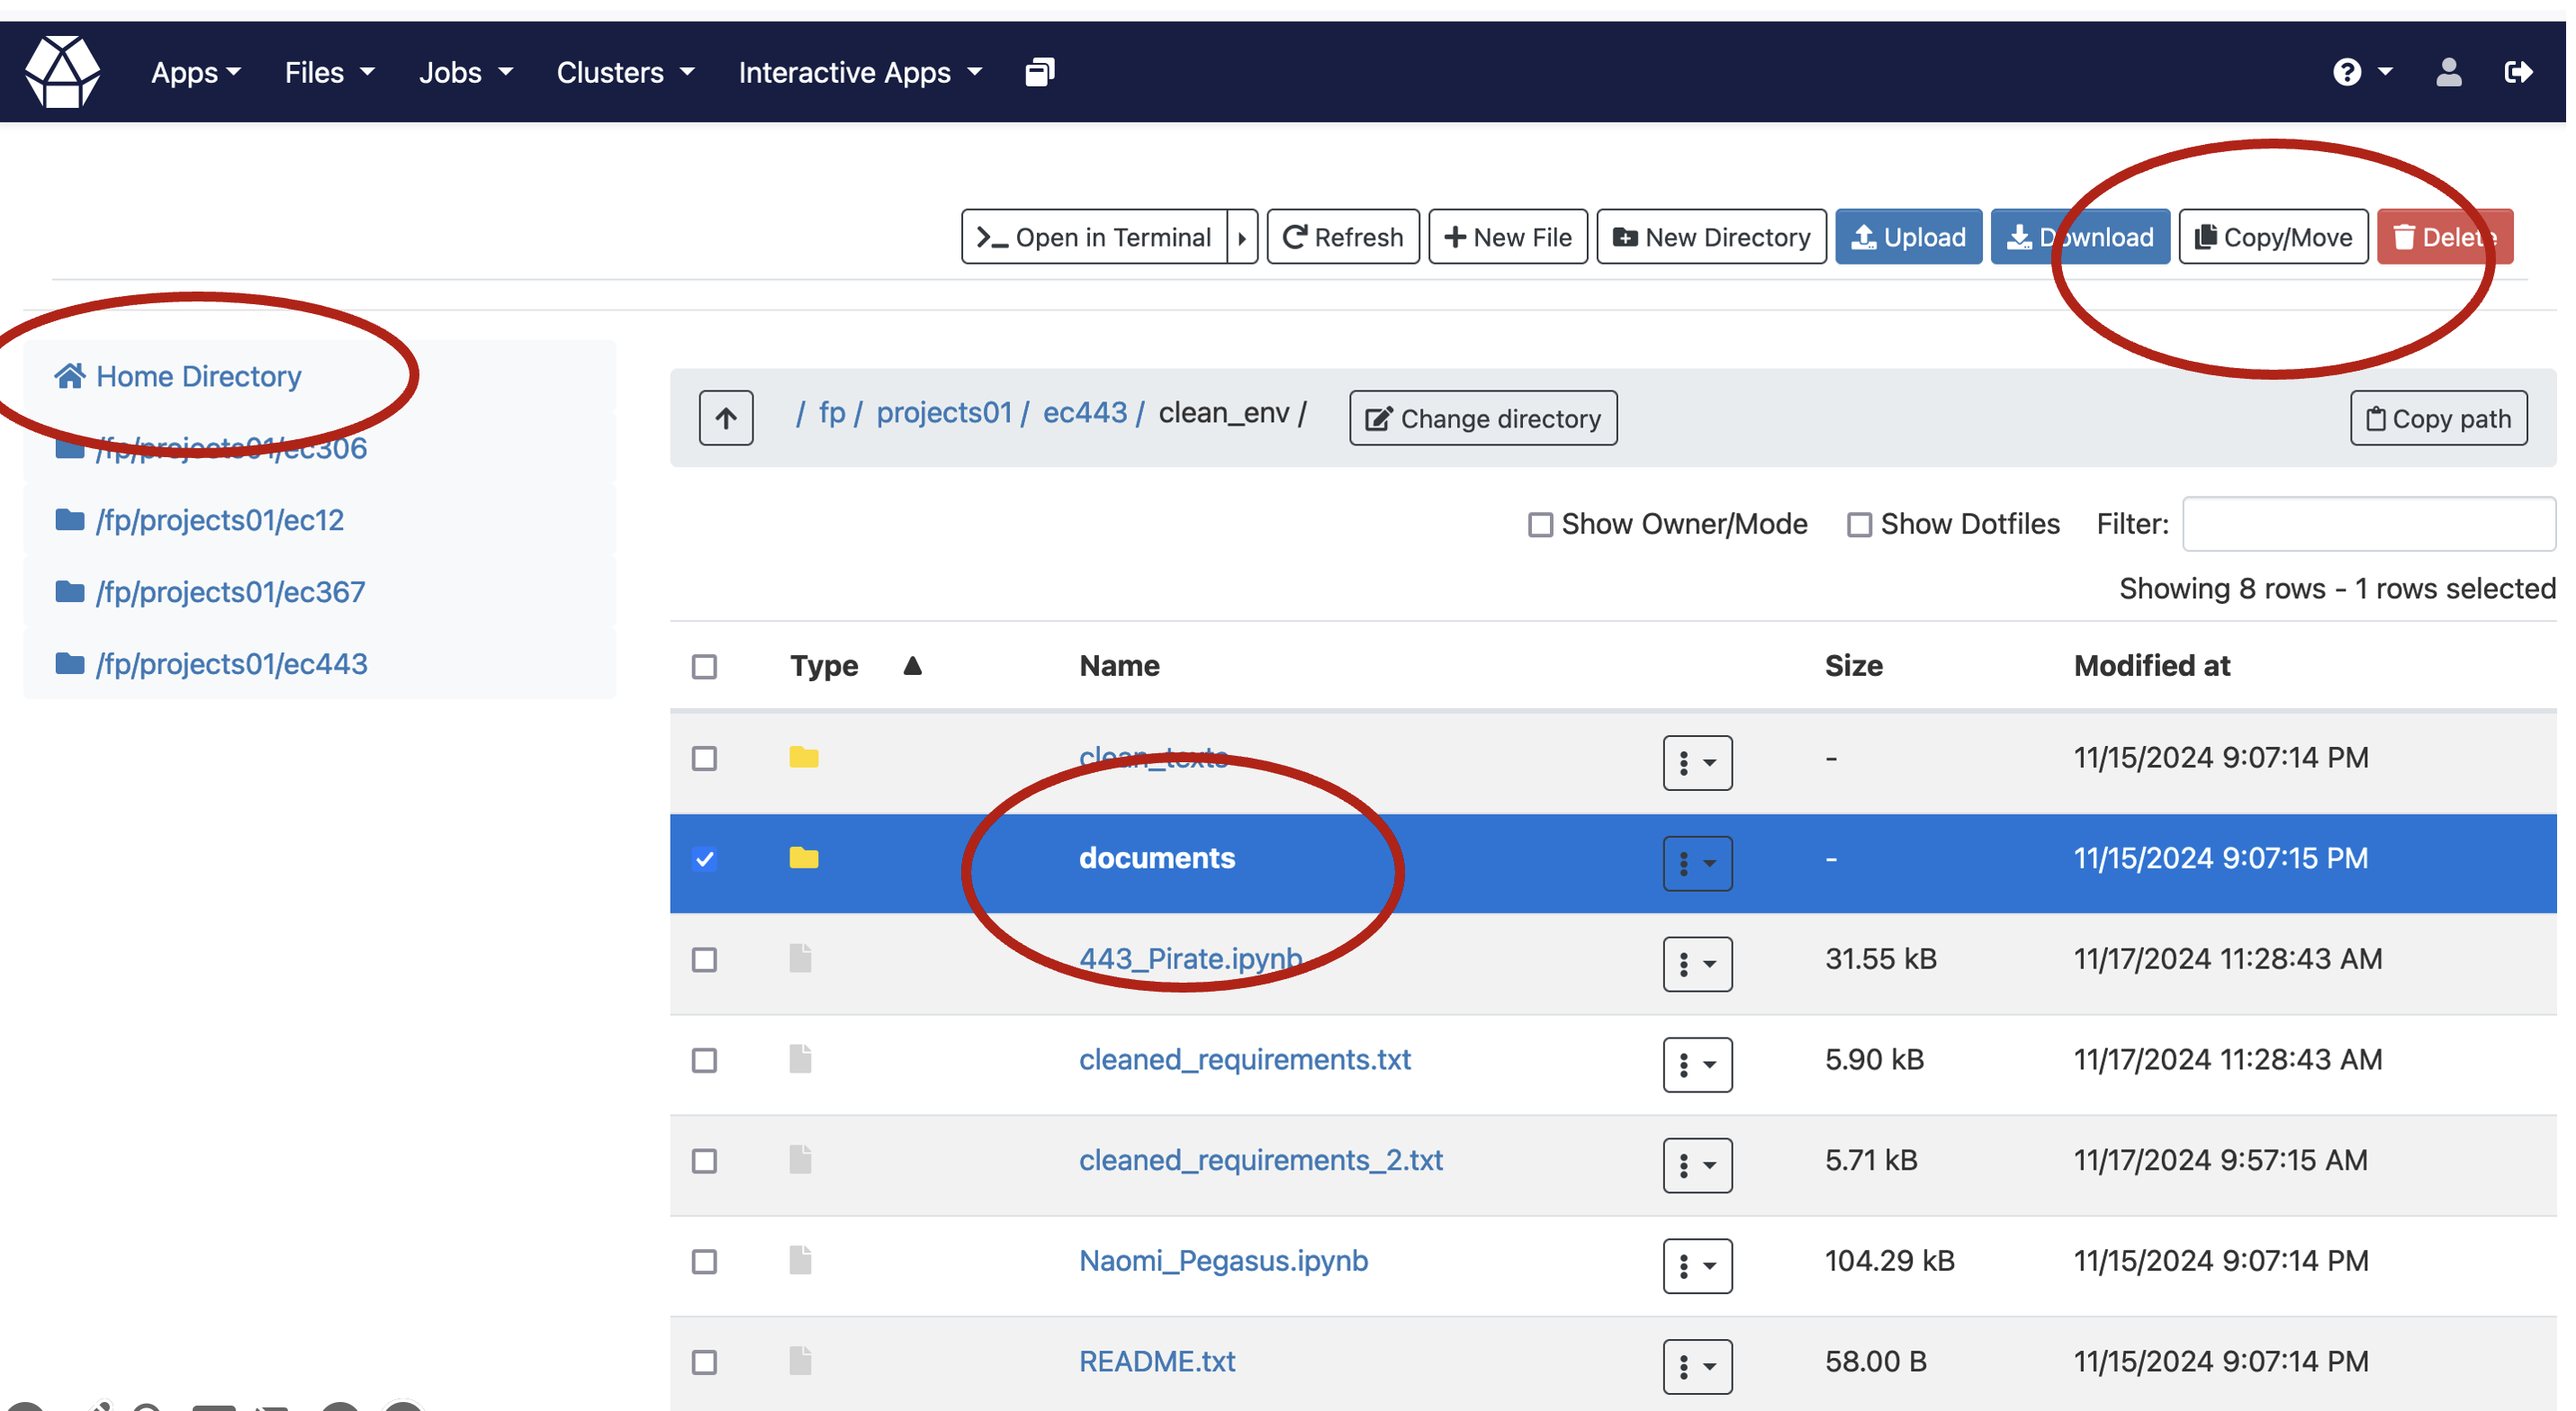

The easiest way doing this, is to use the browser view for Fox. The idea
is that you are a researcher with a specific subject in mind. In this
case, there was a search for "terrorism" and "western europe" in DOAJ.

Note

Task 8.1: Copy all of the content from this path:
/fp/projects01/ec443/documents, and move it into your own documents
folder named "documents" on your own home directory.

Cell 1:

    document_folder = '/fp/projects01/ec443/documents/terrorism'

Repeating the location of the models, just in case

Cell 2:

    %env HF_HOME=/fp/projects01/ec443/huggingface/cache/

Cell 3:

    from langchain_huggingface.llms import HuggingFacePipeline

    llm = HuggingFacePipeline.from_model_id(
          model_id='mistralai/Ministral-8B-Instruct-2410',
          task='text-generation',
          device=0,
          pipeline_kwargs={
              'max_new_tokens': 1000,
              #'do_sample': True,
              #'temperature': 0.3,
              #'num_beams': 4,
          }
      )

# Making a prompt

Cell 4:

    from langchain.chains.combine_documents import create_stuff_documents_chain
    from langchain.chains.llm import LLMChain
    from langchain.prompts import PromptTemplate

Cell 5:

    separator = '\nYour Summary:\n'
    prompt_template = '''Write a summary of the following:

    {context}
    ''' + separator
    prompt = PromptTemplate(template=prompt_template,
                            input_variables=['context'])

# Create chain

The document loader loads each PDF page as a separate ‘document’. This
is partly for technical reasons because that is the way PDFs are
structured. Therefore, we use the chain called
create_stuff_documents_chain which joins multiple documents into a
single large document.

Cell 6:

    chain = create_stuff_documents_chain(llm, prompt)

A function to split the summary from the input. LangChain returns both
the input prompt and the generated response in one long text. To get
only the summary, we must split the summary from the document that we
sent as input.

Cell 7:

    def split_result(result):
        "Split the reply from the prompt, should be done with output parser?"
        position = result.find(separator)
        summary = result[position + len(separator) :]
        return summary

# Loading the Documents

We use LangChain’s DirectoryLoader to load all in files in
document_folder. document_folder is defined at the start of this
Notebook.

Cell 8:

    from langchain_community.document_loaders import DirectoryLoader

    loader = DirectoryLoader(document_folder)
    documents = loader.load()
    print('number of documents:', len(documents))

# Creating the Summaries

Now, we can iterate over these documents with a for-loop.

Cell 9:

    summaries = {}

    for document in documents:
        filename = document.metadata['source']
        print(filename)
        summary = chain.invoke({"context": [document]})
        summary = split_result(summary)
        summaries[filename] = summary
        print('Summary of file', filename)
        print(summary)

# Saving the Summaries to Text Files

Finally, we save the summaries for later use. In the example below, we
save all the summaries in the file summaries.txt.

Cell 10:

    with open('summaries_2.txt', 'w') as outfile:
        for filename in summaries:
            print('Summary of ', filename, file = outfile)
            print(summaries[filename], file=outfile)
            print(file=outfile)

# Make an overall summary

See here under [bonus
material](https://uio-library.github.io/LLM-course/3_summarizing.html)

Note

Task 8.1: The processes of the Chapters Chatbot and Summarization, may
be done on the largest and the second largest GPU at Fox (40GB memory).
As we advance to the next chapter with RAG, we depend on the largest GPU
with its 80GB memory. Make sure you have your job running on the
mentioned GPU resource. Also go to the menu in Jupyter lab, and choose
as shown in the illustration below: Kernel --\> Shut down all kernels.
Now, you are going to open a new workbook, save it with a name you
choose, and run the RAG process in that new document, without any other
content in the cells.

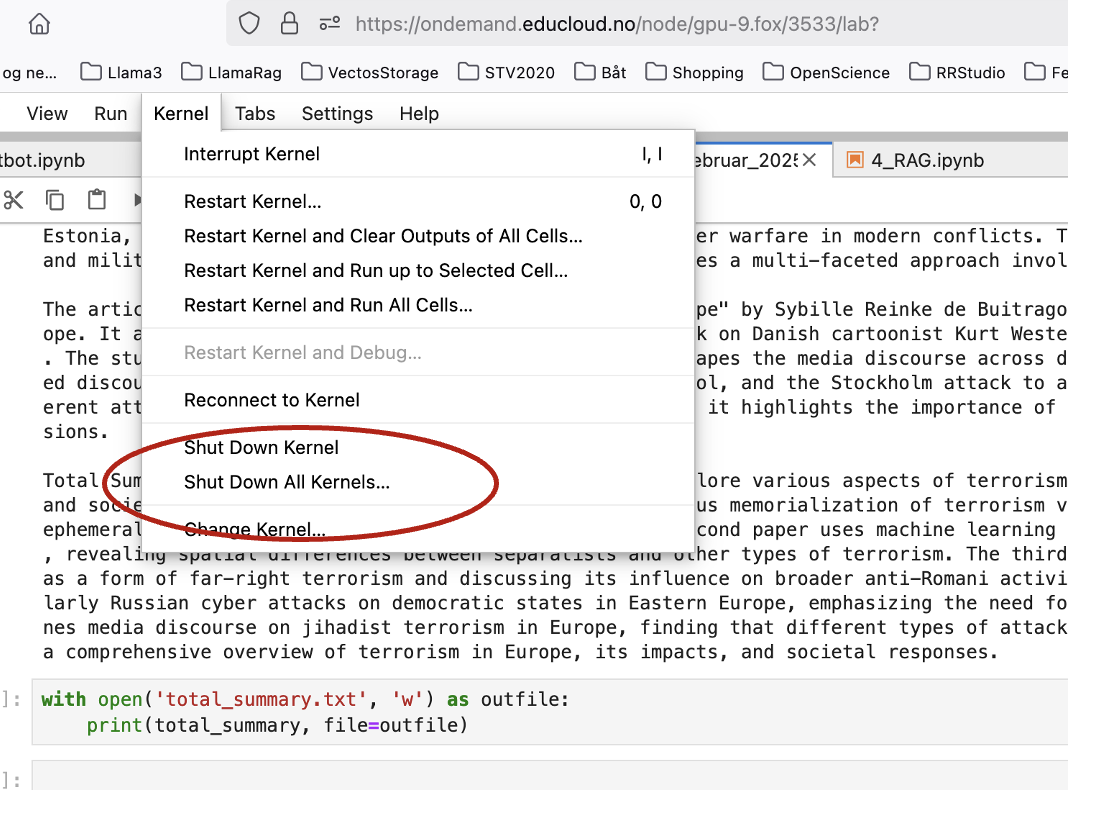

Note

Task 8.2: How can you see if a single kernel is running and how do you
shut them down one by one?